Saving btc_small_all_years.csv to btc_small_all_years (1).csv
Saving usdt-usd-max.csv to usdt-usd-max (1).csv
BTC shape: (45592, 6)


,timestamp,Open,High,Low,Close,Volume
0,2020-01-01 00:00:00,7195.24,7196.25,7175.46,7177.02,511.814
1,2020-01-01 01:00:00,7176.47,7230.00,7175.71,7216.27,883.052
2,2020-01-01 02:00:00,7215.52,7244.87,7211.41,7242.85,655.157
3,2020-01-01 03:00:00,7242.66,7245.00,7220.00,7225.01,783.725
4,2020-01-01 04:00:00,7225.00,7230.00,7215.03,7217.27,467.815


USDT shape: (4044, 2)


,timestamp,usdt_market_cap
0,2015-02-25,304476.0
1,2015-03-02,144046.0
2,2015-03-06,251600.0
3,2015-03-07,251600.0
4,2015-03-08,251600.0


Common range: 2020-01-01 00:00:00 to 2025-03-15 23:00:00
Merged shape: (45592, 7)


/tmp/ipykernel_5151/11843680.py:90: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")


,timestamp,Open,High,Low,Close,Volume,usdt_market_cap
0,2020-01-01 00:00:00,7195.24,7196.25,7175.46,7177.02,511.814,4.285942e+09
1,2020-01-01 01:00:00,7176.47,7230.00,7175.71,7216.27,883.052,4.285942e+09
2,2020-01-01 02:00:00,7215.52,7244.87,7211.41,7242.85,655.157,4.285942e+09
3,2020-01-01 03:00:00,7242.66,7245.00,7220.00,7225.01,783.725,4.285942e+09
4,2020-01-01 04:00:00,7225.00,7230.00,7215.03,7217.27,467.815,4.285942e+09


Final dataset shape: (45521, 14)


,timestamp,Open,High,Low,Close,Volume,usdt_market_cap,return,log_return,volatility_24h,ma_24h,ma_72h,dom_change,volume_change
71,2020-01-03 23:00:00,7301.32,7346.08,7291.75,7344.96,1712.854,4.288899e+09,0.006082,0.006063,0.009599,7239.666250,7184.040000,0.00000,0.216908
72,2020-01-04 00:00:00,7345.00,7350.00,7289.98,7302.24,1240.408,4.283023e+09,-0.005816,-0.005833,0.009654,7254.884583,7185.779167,-0.00137,-0.275824
73,2020-01-04 01:00:00,7304.96,7312.58,7280.85,7309.16,821.319,4.283023e+09,0.000948,0.000947,0.009463,7272.397500,7187.069306,0.00000,-0.337864
74,2020-01-04 02:00:00,7308.71,7328.99,7296.18,7327.83,868.282,4.283023e+09,0.002554,0.002551,0.009332,7287.853750,7188.249583,0.00000,0.057180
75,2020-01-04 03:00:00,7328.21,7339.69,7318.56,7333.11,763.775,4.283023e+09,0.000721,0.000720,0.009317,7303.731667,7189.750972,0.00000,-0.120361


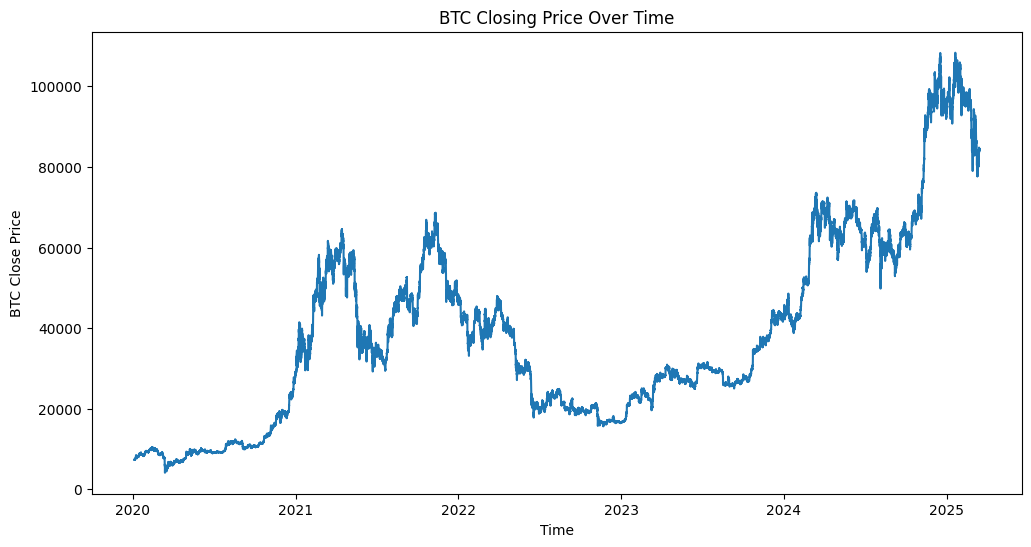

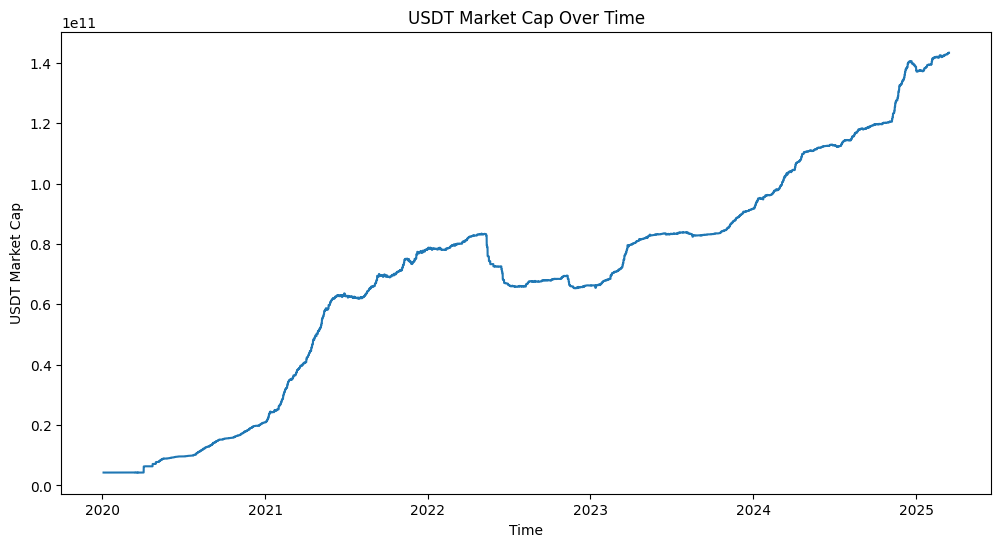

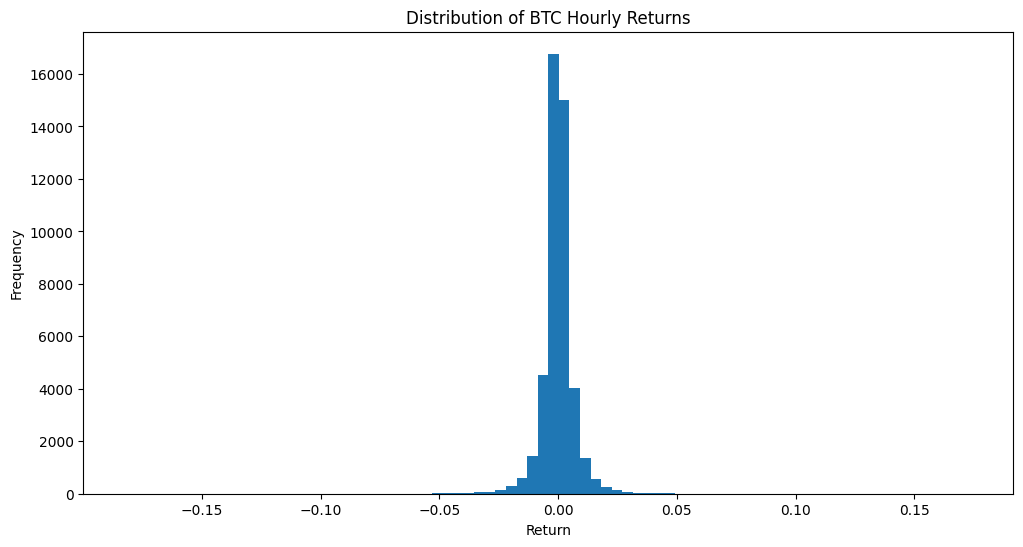


Correlation Matrix:
                    Close    Volume  usdt_market_cap    return  \
Close            1.000000 -0.281969         0.798443  0.002392   
Volume          -0.281969  1.000000        -0.140985 -0.014694   
usdt_market_cap  0.798443 -0.140985         1.000000 -0.007939   
return           0.002392 -0.014694        -0.007939  1.000000   
volatility_24h  -0.004606  0.241343        -0.169492  0.010742   
dom_change      -0.006663  0.002060        -0.026000 -0.004419   

                 volatility_24h  dom_change  
Close                 -0.004606   -0.006663  
Volume                 0.241343    0.002060  
usdt_market_cap       -0.169492   -0.026000  
return                 0.010742   -0.004419  
volatility_24h         1.000000    0.015742  
dom_change             0.015742    1.000000  


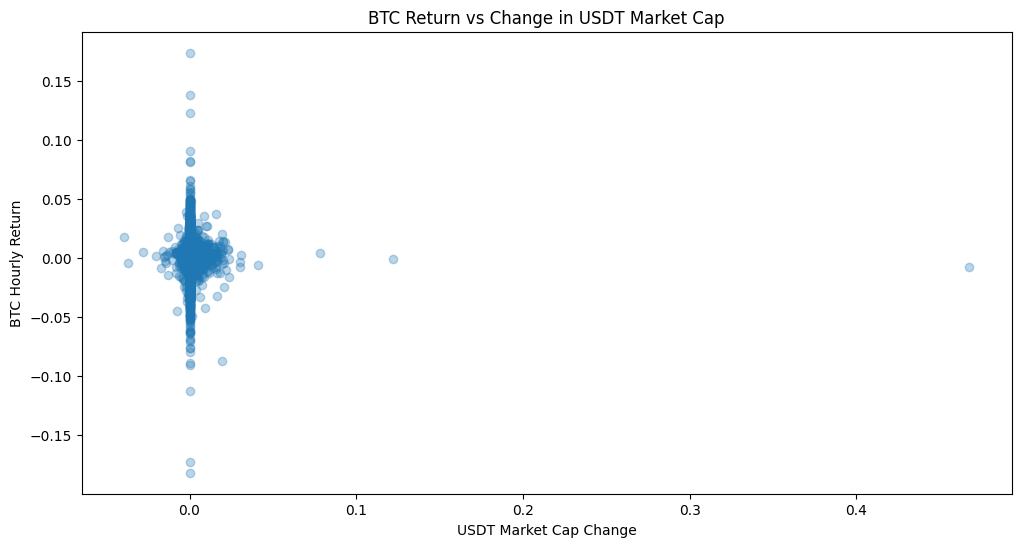


Hypothesis Test 1
Pearson correlation: -0.004418546344924738
p-value: 0.3458321541198373
Result: Fail to reject H0 at the 5% significance level.

Hypothesis Test 2
t-statistic: -44.38266940118365
p-value: 0.0
Result: Reject H0 at the 5% significance level.

================ SHORT FINDINGS ================
1. BTC data from the archive was converted into an hourly dataset.
2. USDT historical market cap data was added as a second dataset.
3. The two datasets were merged successfully using timestamp.
4. Returns, volatility, moving averages, and market cap change variables were created.
5. EDA plots and correlations were produced.
6. Two hypothesis tests were applied.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_ind
from google.colab import files

plt.rcParams["figure.figsize"] = (12, 6)

# -------------------------------------------------
# 1) Upload the two required files
# -------------------------------------------------
# Upload:
# - btc_small_all_years.csv
# - usdt-usd-max.csv
uploaded = files.upload()

# -------------------------------------------------
# 2) Load BTC data
# -------------------------------------------------
btc = pd.read_csv("btc_small_all_years.csv")

btc["Open time"] = pd.to_datetime(btc["Open time"], errors="coerce")
btc = btc[["Open time", "Open", "High", "Low", "Close", "Volume"]].copy()
btc = btc.rename(columns={"Open time": "timestamp"})

for col in ["Open", "High", "Low", "Close", "Volume"]:
    btc[col] = pd.to_numeric(btc[col], errors="coerce")

btc = btc.dropna().sort_values("timestamp")

print("BTC shape:", btc.shape)
display(btc.head())

# -------------------------------------------------
# 3) Load and fix USDT data
# -------------------------------------------------
usdt_raw = pd.read_csv("usdt-usd-max.csv", sep=",")

# If the csv is read as a single column, split it manually
if len(usdt_raw.columns) == 1:
    usdt_raw = usdt_raw.iloc[:, 0].str.split(",", expand=True)
    usdt_raw.columns = ["timestamp", "price", "market_cap", "total_volume"]
else:
    usdt_raw.columns = [c.strip() for c in usdt_raw.columns]

    # rename standard coingecko-like columns if needed
    rename_map = {}
    for c in usdt_raw.columns:
        cl = c.lower()
        if "snapped" in cl or "date" in cl:
            rename_map[c] = "timestamp"
        elif cl == "price" or "price" in cl:
            rename_map[c] = "price"
        elif "market_cap" in cl or ("market" in cl and "cap" in cl):
            rename_map[c] = "market_cap"
        elif "total_volume" in cl or ("total" in cl and "volume" in cl):
            rename_map[c] = "total_volume"
    usdt_raw = usdt_raw.rename(columns=rename_map)

# Keep only timestamp and market cap
usdt = usdt_raw[["timestamp", "market_cap"]].copy()
usdt.columns = ["timestamp", "usdt_market_cap"]

# Clean values
usdt["timestamp"] = pd.to_datetime(
    usdt["timestamp"].astype(str).str.replace(" UTC", "", regex=False),
    errors="coerce"
)

usdt["usdt_market_cap"] = (
    usdt["usdt_market_cap"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(r"[^0-9.\-]", "", regex=True)
)

usdt["usdt_market_cap"] = pd.to_numeric(usdt["usdt_market_cap"], errors="coerce")
usdt = usdt.dropna().sort_values("timestamp")

print("USDT shape:", usdt.shape)
display(usdt.head())

# -------------------------------------------------
# 4) Convert USDT daily data to hourly
# -------------------------------------------------
usdt_hourly = (
    usdt.set_index("timestamp")
        .resample("1H")
        .ffill()
        .reset_index()
)

# -------------------------------------------------
# 5) Align common date range
# -------------------------------------------------
start = max(btc["timestamp"].min(), usdt_hourly["timestamp"].min())
end = min(btc["timestamp"].max(), usdt_hourly["timestamp"].max())

btc = btc[(btc["timestamp"] >= start) & (btc["timestamp"] <= end)].copy()
usdt_hourly = usdt_hourly[(usdt_hourly["timestamp"] >= start) & (usdt_hourly["timestamp"] <= end)].copy()

print("Common range:", start, "to", end)

# -------------------------------------------------
# 6) Merge datasets
# -------------------------------------------------
df = pd.merge(btc, usdt_hourly, on="timestamp", how="inner")

print("Merged shape:", df.shape)
display(df.head())

# -------------------------------------------------
# 7) Feature Engineering
# -------------------------------------------------
df["return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["volatility_24h"] = df["return"].rolling(24).std()
df["ma_24h"] = df["Close"].rolling(24).mean()
df["ma_72h"] = df["Close"].rolling(72).mean()
df["dom_change"] = df["usdt_market_cap"].pct_change()
df["volume_change"] = df["Volume"].pct_change()

df = df.dropna().copy()

print("Final dataset shape:", df.shape)
display(df.head())

# -------------------------------------------------
# 8) Save merged dataset
# -------------------------------------------------
df.to_csv("final_dataset.csv", index=False)

# -------------------------------------------------
# 9) Exploratory Data Analysis (EDA)
# -------------------------------------------------

# BTC price over time
plt.figure()
plt.plot(df["timestamp"], df["Close"])
plt.title("BTC Closing Price Over Time")
plt.xlabel("Time")
plt.ylabel("BTC Close Price")
plt.show()

# USDT market cap over time
plt.figure()
plt.plot(df["timestamp"], df["usdt_market_cap"])
plt.title("USDT Market Cap Over Time")
plt.xlabel("Time")
plt.ylabel("USDT Market Cap")
plt.show()

# Distribution of returns
plt.figure()
plt.hist(df["return"], bins=80)
plt.title("Distribution of BTC Hourly Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

# Correlation matrix
print("\nCorrelation Matrix:")
print(df[["Close", "Volume", "usdt_market_cap", "return", "volatility_24h", "dom_change"]].corr())

# Scatter plot
plt.figure()
plt.scatter(df["dom_change"], df["return"], alpha=0.3)
plt.title("BTC Return vs Change in USDT Market Cap")
plt.xlabel("USDT Market Cap Change")
plt.ylabel("BTC Hourly Return")
plt.show()

# -------------------------------------------------
# 10) Hypothesis Test 1
# -------------------------------------------------
# H0: There is no linear relationship between USDT market cap change and BTC return.
# H1: There is a significant linear relationship between them.
r, p = pearsonr(df["dom_change"], df["return"])

print("\nHypothesis Test 1")
print("Pearson correlation:", r)
print("p-value:", p)

if p < 0.05:
    print("Result: Reject H0 at the 5% significance level.")
else:
    print("Result: Fail to reject H0 at the 5% significance level.")

# -------------------------------------------------
# 11) Hypothesis Test 2
# -------------------------------------------------
# H0: Mean volatility is the same in high and low USDT market cap periods.
# H1: Mean volatility is different between the two periods.
median_cap = df["usdt_market_cap"].median()

high = df[df["usdt_market_cap"] >= median_cap]["volatility_24h"]
low = df[df["usdt_market_cap"] < median_cap]["volatility_24h"]

t_stat, p2 = ttest_ind(high, low, equal_var=False, nan_policy="omit")

print("\nHypothesis Test 2")
print("t-statistic:", t_stat)
print("p-value:", p2)

if p2 < 0.05:
    print("Result: Reject H0 at the 5% significance level.")
else:
    print("Result: Fail to reject H0 at the 5% significance level.")

# -------------------------------------------------
# 12) Short findings
# -------------------------------------------------
print("\n================ SHORT FINDINGS ================")
print("1. BTC data from the archive was converted into an hourly dataset.")
print("2. USDT historical market cap data was added as a second dataset.")
print("3. The two datasets were merged successfully using timestamp.")
print("4. Returns, volatility, moving averages, and market cap change variables were created.")
print("5. EDA plots and correlations were produced.")
print("6. Two hypothesis tests were applied.")
print("================================================")

# -------------------------------------------------
# 13) Download final dataset
# -------------------------------------------------
files.download("final_dataset.csv")